# 04 Model Development

Objective

Develop and compare traditional econometric models and machine learning models for modelling asymmetric exchange rate pass-through in South African food prices.

In [223]:
#Data manipulation
import pandas as pd
import numpy as np

#Visualisation
import matplotlib.pyplot as plt
import seaborn as sns

#Machine Learning
from sklearn.model_selection import TimeSeriesSplit
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

#Gradient Boosting
import xgboost as xgb

# Econometrics
from statsmodels.tsa.api import VAR
from statsmodels.tsa.ardl import UECM
from statsmodels.tsa.ardl import ARDL

#Time Series Analysis
from statsmodels.tsa.stattools import adfuller


In [224]:
#load feature engineered dataset
data = pd.read_csv("../data/processed/featured_data.csv")

data.head()

,Date,DivisionDescription,GroupDescription,ClassDescription,SubclassDescription,Weight,Eight digit code,CPI,ExchangeRate,Year,Month,Quarter,ExchangeRate_Lag1,ExchangeRate_Lag2,ExchangeRate_Lag6,CPI_Lag1,CPI_Lag3,ExchangeRate_Change,Depreciation,Appreciation,ExchangeRate_MA3,ExchangeRate_STD3,Food_Category
0,2015-07-01,Food and non-alcoholic beverages,Food,Cereal products,Cereals,0.540243,1111201,57.2,12.452687,2015,7,3,12.303048,12.012553,11.566500,57.0,57.0,0.012163,0.012163,0.000000,12.241892,0.247116,4
1,2015-08-01,Food and non-alcoholic beverages,Food,Cereal products,Cereals,0.540243,1111201,59.3,12.914595,2015,8,3,12.452687,11.969940,11.577440,57.2,57.3,0.037093,0.037093,0.000000,12.556777,0.318784,4
2,2015-09-01,Food and non-alcoholic beverages,Food,Cereal products,Cereals,0.540243,1111201,58.9,13.610852,2015,9,3,12.914595,12.303048,12.068727,59.3,57.0,0.053912,0.053912,0.000000,12.992711,0.583021,4
3,2015-10-01,Food and non-alcoholic beverages,Food,Cereal products,Cereals,0.540243,1111201,59.5,13.504323,2015,10,4,13.610852,12.452687,12.012553,58.9,57.2,-0.007827,0.000000,0.007827,13.343257,0.375034,4
4,2015-11-01,Food and non-alcoholic beverages,Food,Cereal products,Cereals,0.540243,1111201,58.9,14.125733,2015,11,4,13.504323,12.914595,11.969940,59.5,59.3,0.046016,0.046016,0.000000,13.746969,0.332316,4


In [225]:
#inspect the dataset
data.info()

<class 'pandas.DataFrame'>
RangeIndex: 14150 entries, 0 to 14149
Data columns (total 23 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   Date                 14150 non-null  str    
 1   DivisionDescription  14150 non-null  str    
 2   GroupDescription     14150 non-null  str    
 3   ClassDescription     14150 non-null  str    
 4   SubclassDescription  14150 non-null  str    
 5   Weight               14150 non-null  float64
 6   Eight digit code     14150 non-null  int64  
 7   CPI                  14150 non-null  float64
 8   ExchangeRate         14150 non-null  float64
 9   Year                 14150 non-null  int64  
 10  Month                14150 non-null  int64  
 11  Quarter              14150 non-null  int64  
 12  ExchangeRate_Lag1    14150 non-null  float64
 13  ExchangeRate_Lag2    14150 non-null  float64
 14  ExchangeRate_Lag6    14150 non-null  float64
 15  CPI_Lag1             14150 non-null  float64
 1

In [226]:
data.describe()

,Weight,Eight digit code,CPI,ExchangeRate,Year,Month,Quarter,ExchangeRate_Lag1,ExchangeRate_Lag2,ExchangeRate_Lag6,CPI_Lag1,CPI_Lag3,ExchangeRate_Change,Depreciation,Appreciation,ExchangeRate_MA3,ExchangeRate_STD3,Food_Category
count,14150.000000,1.415000e+04,14150.000000,14150.000000,14150.000000,14150.000000,14150.000000,14150.000000,14150.000000,14150.000000,14150.000000,14150.000000,14150.000000,14150.000000,14150.000000,14150.000000,14150.000000,14150.000000
mean,0.144390,1.160668e+06,80.513258,15.794418,2020.459293,6.653852,2.550883,15.760464,15.681964,15.547186,80.141845,79.395081,0.002929,0.014649,0.011720,15.758757,0.369359,23.328905
std,0.190869,3.739225e+04,15.720060,2.054620,3.021960,3.437996,1.113747,2.076117,2.117505,2.167035,15.699572,15.626240,0.033929,0.023775,0.015573,2.044655,0.247968,13.685660
min,0.010375,1.111201e+06,40.100000,11.824600,2015.000000,1.000000,1.000000,11.824600,11.824600,11.566500,40.100000,40.100000,-0.074539,0.000000,0.000000,11.915853,0.053243,0.000000
25%,0.032154,1.124004e+06,68.100000,14.091309,2018.000000,4.000000,2.000000,14.081841,14.047787,13.923768,67.700000,67.200000,-0.019830,0.000000,0.000000,14.113855,0.200526,13.000000
50%,0.089114,1.161201e+06,78.700000,15.215175,2021.000000,7.000000,3.000000,15.146414,15.062438,14.984636,78.200000,77.500000,-0.004332,0.000000,0.004332,15.231720,0.315739,22.000000
75%,0.173193,1.186001e+06,95.300000,17.836520,2023.000000,10.000000,4.000000,17.836520,17.836520,17.836520,94.900000,93.900000,0.022168,0.022168,0.019830,17.751849,0.473305,35.000000
max,1.447038,1.290001e+06,172.100000,19.065941,2025.000000,12.000000,4.000000,19.065941,19.065941,19.065941,172.100000,172.100000,0.115651,0.115651,0.074539,18.929468,1.784508,48.000000


In [227]:
#define target variable
target = "CPI"

In [228]:
#define features
X = data.drop(
    columns=[
        "Date",
        "SubclassDescription",
        "CPI"
    ]
)

y = data[target]

In [229]:
print(f"Predictor Matrix Shape: {X.shape}")
print(f"Target Variable Shape : {y.shape}")

Predictor Matrix Shape: (14150, 20)
Target Variable Shape : (14150,)


In [230]:
#Chronological Train-Test Split
split_index = int(len(data) * 0.80)

X_train = X.iloc[:split_index]
X_test = X.iloc[split_index:]

y_train = y.iloc[:split_index]
y_test = y.iloc[split_index:]

In [231]:
print(f"Training Samples : {len(X_train)}")
print(f"Testing Samples  : {len(X_test)}")

Training Samples : 11320
Testing Samples  : 2830


In [232]:
print("Training Period")
print(data.iloc[:split_index]["Date"].min())
print(data.iloc[:split_index]["Date"].max())

print("\nTesting Period")
print(data.iloc[split_index:]["Date"].min())
print(data.iloc[split_index:]["Date"].max())

Training Period
2015-07-01
2025-12-01

Testing Period
2015-07-01
2025-12-01


In [233]:
econometric_data = data.copy()
ml_data = data.copy()

# Econometric Modelling

This section develops the traditional econometric models used in the study.

The econometric models serve as the benchmark against which the machine learning models will be compared.

The following models are considered:

- Nonlinear Autoregressive Distributed Lag (NARDL)
- Vector Autoregression (VAR)

Before estimating these models, the time series properties of the variables are examined to determine whether they satisfy the assumptions required for econometric analysis.

In [234]:
#Select Variables for Econometric Analysis
econometric_data["Date"] = pd.to_datetime(econometric_data["Date"])

econometric_data.set_index("Date", inplace=True)

In [235]:
econometric_data.head()

,DivisionDescription,GroupDescription,ClassDescription,SubclassDescription,Weight,Eight digit code,CPI,ExchangeRate,Year,Month,Quarter,ExchangeRate_Lag1,ExchangeRate_Lag2,ExchangeRate_Lag6,CPI_Lag1,CPI_Lag3,ExchangeRate_Change,Depreciation,Appreciation,ExchangeRate_MA3,ExchangeRate_STD3,Food_Category
Date,,,,,,,,,,,,,,,,,,,,,,
2015-07-01,Food and non-alcoholic beverages,Food,Cereal products,Cereals,0.540243,1111201,57.2,12.452687,2015,7,3,12.303048,12.012553,11.566500,57.0,57.0,0.012163,0.012163,0.000000,12.241892,0.247116,4
2015-08-01,Food and non-alcoholic beverages,Food,Cereal products,Cereals,0.540243,1111201,59.3,12.914595,2015,8,3,12.452687,11.969940,11.577440,57.2,57.3,0.037093,0.037093,0.000000,12.556777,0.318784,4
2015-09-01,Food and non-alcoholic beverages,Food,Cereal products,Cereals,0.540243,1111201,58.9,13.610852,2015,9,3,12.914595,12.303048,12.068727,59.3,57.0,0.053912,0.053912,0.000000,12.992711,0.583021,4
2015-10-01,Food and non-alcoholic beverages,Food,Cereal products,Cereals,0.540243,1111201,59.5,13.504323,2015,10,4,13.610852,12.452687,12.012553,58.9,57.2,-0.007827,0.000000,0.007827,13.343257,0.375034,4
2015-11-01,Food and non-alcoholic beverages,Food,Cereal products,Cereals,0.540243,1111201,58.9,14.125733,2015,11,4,13.504323,12.914595,11.969940,59.5,59.3,0.046016,0.046016,0.000000,13.746969,0.332316,4


In [236]:
econometric_data.info()

<class 'pandas.DataFrame'>
DatetimeIndex: 14150 entries, 2015-07-01 to 2025-12-01
Data columns (total 22 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   DivisionDescription  14150 non-null  str    
 1   GroupDescription     14150 non-null  str    
 2   ClassDescription     14150 non-null  str    
 3   SubclassDescription  14150 non-null  str    
 4   Weight               14150 non-null  float64
 5   Eight digit code     14150 non-null  int64  
 6   CPI                  14150 non-null  float64
 7   ExchangeRate         14150 non-null  float64
 8   Year                 14150 non-null  int64  
 9   Month                14150 non-null  int64  
 10  Quarter              14150 non-null  int64  
 11  ExchangeRate_Lag1    14150 non-null  float64
 12  ExchangeRate_Lag2    14150 non-null  float64
 13  ExchangeRate_Lag6    14150 non-null  float64
 14  CPI_Lag1             14150 non-null  float64
 15  CPI_Lag3             14150 non

In [237]:
#Select Variables for Econometric Analysis
econ_df = econometric_data[
    [
        "CPI",
        "ExchangeRate",
        "Depreciation",
        "Appreciation"
    ]
].copy()

In [238]:
econ_df.head()

,CPI,ExchangeRate,Depreciation,Appreciation
Date,,,,
2015-07-01,57.2,12.452687,0.012163,0.000000
2015-08-01,59.3,12.914595,0.037093,0.000000
2015-09-01,58.9,13.610852,0.053912,0.000000
2015-10-01,59.5,13.504323,0.000000,0.007827
2015-11-01,58.9,14.125733,0.046016,0.000000


In [239]:
print(econ_df.columns.tolist())

['CPI', 'ExchangeRate', 'Depreciation', 'Appreciation']


In [240]:
def adf_test(series):

    result = adfuller(series.dropna())

    return {
        "ADF Statistic": result[0],
        "p-value": result[1],
        "Lags": result[2],
        "Observations": result[3],
        "Stationary":
            "Yes"
            if result[1] < 0.05
            else "No"
    }

In [241]:
stationarity_results = pd.DataFrame()

for column in econ_df.columns:

    results = adf_test(econ_df[column])

    results["Variable"] = column

    stationarity_results = pd.concat(
        [
            stationarity_results,
            pd.DataFrame([results])
        ],
        ignore_index=True
    )

In [242]:
stationarity_results = stationarity_results[
    [
        "Variable",
        "ADF Statistic",
        "p-value",
        "Lags",
        "Observations",
        "Stationary"
    ]
]

stationarity_results

,Variable,ADF Statistic,p-value,Lags,Observations,Stationary
0,CPI,-19.330786,0.0,37,14112,Yes
1,ExchangeRate,-19.451890,0.0,42,14107,Yes
2,Depreciation,-23.090837,0.0,40,14109,Yes
3,Appreciation,-24.560047,0.0,42,14107,Yes


### Interpretation

The Augmented Dickey-Fuller (ADF) test was performed to assess the stationarity of the variables selected for econometric modelling.

The results indicate that all variables have p-values below the 5% significance level, leading to the rejection of the null hypothesis of a unit root. Consequently, the Consumer Price Index (CPI), Exchange Rate, Depreciation, and Appreciation variables are all considered stationary.

These findings suggest that the selected variables satisfy the stationarity assumption required for subsequent econometric modelling. Therefore, the study proceeds to determine the optimal lag structure before estimating the NARDL and VAR models.

In [243]:
#lag order selection
from statsmodels.tsa.api import VAR

In [244]:
lag_selection = VAR(econ_df)

lag_results = lag_selection.select_order(maxlags=12)

lag_results.summary()

d:\ERPT_ML_Research\.venv\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
d:\ERPT_ML_Research\.venv\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it is not monotonic and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)


,AIC,BIC,FPE,HQIC
0,-10.04,-10.04,4.353e-05,-10.04
1,-16.40,-16.39,7.514e-08,-16.40
2,-16.50,-16.48,6.823e-08,-16.49
3,-16.53,-16.50,6.649e-08,-16.52
4,-16.57,-16.53,6.392e-08,-16.55
5,-16.61,-16.57,6.092e-08,-16.60
6,-16.63,-16.58,5.976e-08,-16.62
7,-16.73,-16.67,5.420e-08,-16.71
8,-16.85,-16.78,4.789e-08,-16.83
9,-16.91,-16.83,4.552e-08,-16.88


In [245]:
optimal_lag = lag_results.aic

print(f"Optimal lag selected by AIC: {optimal_lag}")

Optimal lag selected by AIC: 12


### Interpretation

The optimal lag order for the Vector Autoregression (VAR) model was determined using four commonly used information criteria:

- Akaike Information Criterion (AIC)
- Bayesian Information Criterion (BIC)
- Final Prediction Error (FPE)
- Hannan-Quinn Information Criterion (HQIC)

All four criteria selected a lag length of **12**, as indicated by the asterisks in the lag selection table. This suggests that incorporating twelve lagged observations provides the best balance between model fit and complexity for the variables included in the analysis.

Consequently, a lag order of **12** will be adopted for the estimation of the VAR model. The same lag structure will also serve as an initial reference when specifying the NARDL model, although the optimal lag structure for NARDL may differ depending on the selected autoregressive and distributed lag orders.

In [246]:
# Split the econometric dataset into training and testing sets
econ_train = econ_df.iloc[:split_index]
econ_test = econ_df.iloc[split_index:]

print(f"Training observations: {len(econ_train)}")
print(f"Testing observations : {len(econ_test)}")

Training observations: 11320
Testing observations : 2830


In [247]:
# Fit the VAR model using only the training data
var_model = VAR(econ_train)

var_results = var_model.fit(optimal_lag)

d:\ERPT_ML_Research\.venv\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
d:\ERPT_ML_Research\.venv\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it is not monotonic and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)


In [248]:
#model information
print(f"Lag Order Used : {var_results.k_ar}")

print(f"Number of Equations : {var_results.neqs}")

print(f"Number of Observations : {var_results.nobs}")

Lag Order Used : 12
Number of Equations : 4
Number of Observations : 11308


In [249]:
#generate forecasts
forecast_input = econ_train.values[-optimal_lag:]

In [250]:
# Forecast over the entire testing period
var_forecast = var_results.forecast(
    y=forecast_input,
    steps=len(econ_test)
)

In [251]:
forecast_df = pd.DataFrame(
    var_forecast,
    columns=econ_train.columns,
    index=econ_test.index
)

forecast_df.head()

,CPI,ExchangeRate,Depreciation,Appreciation
Date,,,,
2019-01-01,83.709020,14.710677,0.029418,0.001117
2019-02-01,82.487946,14.863238,0.027156,0.009193
2019-03-01,82.742504,15.064396,0.024209,0.010223
2019-04-01,84.119248,15.363687,0.025078,0.014102
2019-05-01,83.739605,15.522686,0.023077,0.009033


In [252]:
comparison = pd.DataFrame({
    "Actual CPI": actual_cpi.values,
    "Forecast CPI": forecast_df["CPI"].values
})

In [253]:
# Actual and forecast CPI
actual_cpi = econ_test["CPI"].reset_index(drop=True)
forecast_cpi = forecast_df["CPI"].reset_index(drop=True)

# Ensure equal length
min_len = min(len(actual_cpi), len(forecast_cpi))

comparison = pd.DataFrame({
    "Actual CPI": actual_cpi.iloc[:min_len].values,
    "Forecast CPI": forecast_cpi.iloc[:min_len].values
})

comparison.head()

,Actual CPI,Forecast CPI
0,85.2,83.709020
1,83.8,82.487946
2,84.5,82.742504
3,84.2,84.119248
4,85.4,83.739605


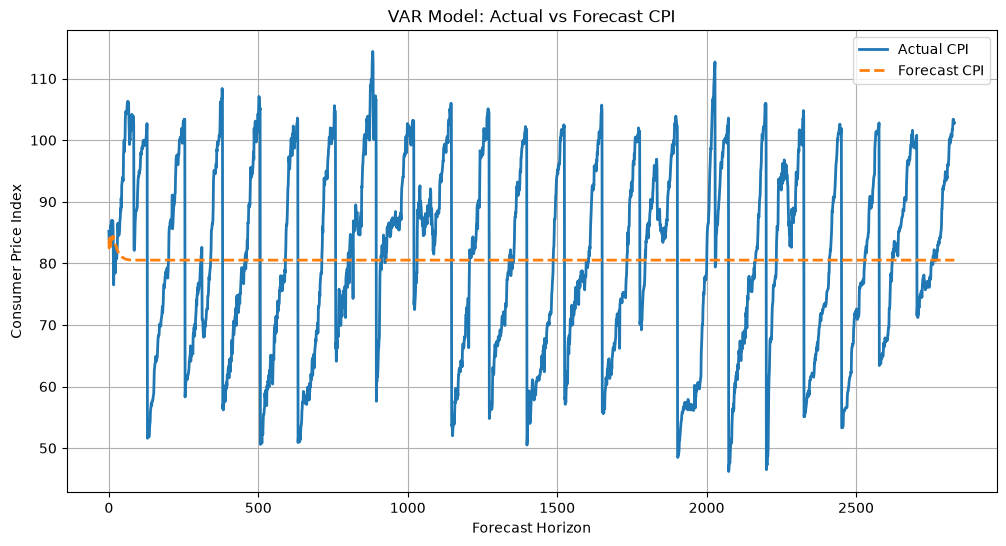

In [254]:
plt.figure(figsize=(12,6))

plt.plot(
    comparison["Actual CPI"],
    label="Actual CPI",
    linewidth=2
)

plt.plot(
    comparison["Forecast CPI"],
    linestyle="--",
    linewidth=2,
    label="Forecast CPI"
)

plt.title("VAR Model: Actual vs Forecast CPI")

plt.xlabel("Forecast Horizon")

plt.ylabel("Consumer Price Index")

plt.legend()

plt.grid(True)

plt.show()

In [255]:
#save
from pathlib import Path

TABLES_DIR = Path("../reports/tables")
TABLES_DIR.mkdir(parents=True, exist_ok=True)

comparison.to_csv(
    TABLES_DIR / "var_forecast_comparison.csv",
    index=False
)

print("Comparison table saved successfully!")

Comparison table saved successfully!


### Interpretation

The comparison between the observed and forecasted Consumer Price Index (CPI) values indicates that the VAR model consistently underestimates food price inflation over the forecasting horizon.

While the actual CPI remains relatively stable, the forecasted values exhibit a persistent downward trend, resulting in an increasing divergence between the observed and predicted values.

These results suggest that the current VAR specification does not fully capture the underlying dynamics of food price movements. Possible reasons include omitted explanatory variables, limitations of the selected lag structure, or the inability of a linear VAR model to adequately represent nonlinear relationships between exchange rate movements and food prices.

In [256]:
# Exchange rate first difference
econ_df["ExchangeRate_Diff"] = econ_df["ExchangeRate"].diff()

In [257]:
# Positive changes
econ_df["Positive_ER"] = (
    econ_df["ExchangeRate_Diff"]
    .clip(lower=0)
    .cumsum()
)

In [258]:
# Negative changes
econ_df["Negative_ER"] = (
    econ_df["ExchangeRate_Diff"]
    .clip(upper=0)
    .cumsum()
)

In [259]:
econ_df[
    [
        "ExchangeRate",
        "Positive_ER",
        "Negative_ER"
    ]
].head(10)

,ExchangeRate,Positive_ER,Negative_ER
Date,,,
2015-07-01,12.452687,NaN,NaN
2015-08-01,12.914595,0.461908,0.000000
2015-09-01,13.610852,1.158165,0.000000
2015-10-01,13.504323,1.158165,-0.106530
2015-11-01,14.125733,1.779576,-0.106530
2015-12-01,14.936148,2.589990,-0.106530
2016-01-01,16.389125,4.042968,-0.106530
2016-02-01,15.774610,4.042968,-0.721045
2016-03-01,15.426575,4.042968,-1.069080


- Positive_ER only increases when the exchange rate rises
- Negative_ER only becomes more negative when the exchange rate falls.

###  Nonlinear ARDL (NARDL)

The VAR model assumes a symmetric relationship between exchange rates and consumer prices.

However, previous literature (Shin et al., 2014) suggests that exchange rate depreciations and appreciations may affect prices differently.

To capture this asymmetry, we decompose exchange rate changes into positive and negative cumulative partial sums before estimating the NARDL model.